<a href="https://colab.research.google.com/github/aysenuruyar-rgb/DSA210-Proj/blob/main/notebook/02_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

final_data = pd.read_csv("final_dataset.csv", index_col=0)
final_data.index = pd.to_datetime(final_data.index)

final_data.head()
final_data.info()
final_data.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 196 entries, 2005-01-31 to 2021-04-30
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   GENERAL_DAM_OCCUPANCY_RATE  196 non-null    float64
 1   GENERAL_DAM_RESERVED_WATER  196 non-null    float64
 2   precipitation_sum (mm)      196 non-null    float64
 3   temperature_2m_mean (°C)    196 non-null    float64
 4   rain_sum (mm)               196 non-null    float64
 5   snowfall_sum (cm)           196 non-null    float64
dtypes: float64(6)
memory usage: 10.7 KB


,GENERAL_DAM_OCCUPANCY_RATE,GENERAL_DAM_RESERVED_WATER,precipitation_sum (mm),temperature_2m_mean (°C),rain_sum (mm),snowfall_sum (cm)
count,196.000000,196.000000,196.000000,196.000000,196.000000,196.000000
mean,64.861690,563.397437,57.812755,14.871435,54.771939,2.191786
std,23.217389,201.703248,41.618465,6.764106,39.166955,5.993851
min,12.230968,106.387097,0.800000,2.767742,0.800000,0.000000
25%,48.431214,420.601786,26.300000,8.441935,25.425000,0.000000
50%,67.276613,584.483871,51.550000,14.537097,50.000000,0.000000
75%,85.827857,745.587500,81.025000,21.352500,78.800000,0.140000
max,98.714839,857.580645,252.400000,26.545161,252.400000,37.170000


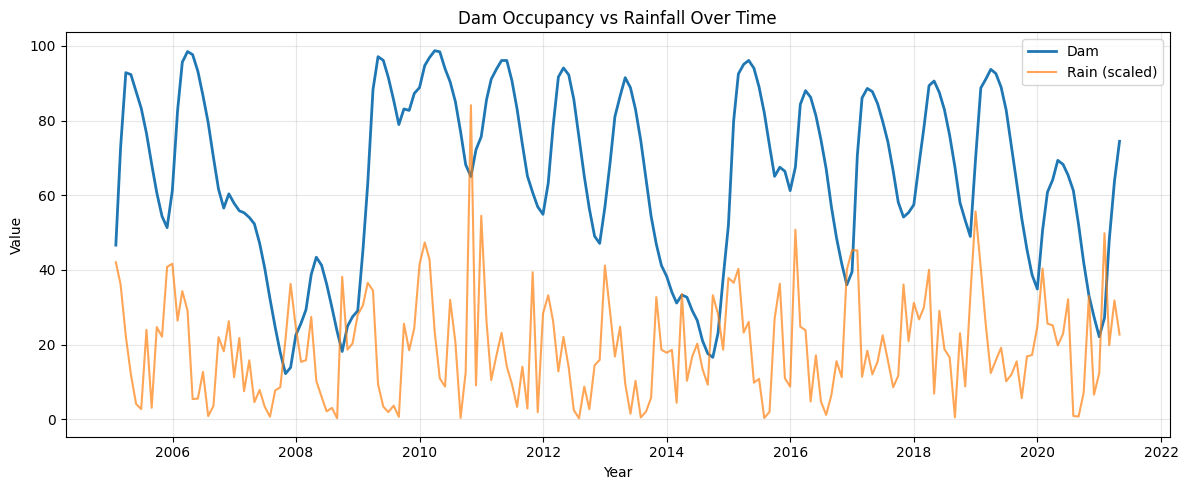

In [28]:
plt.figure(figsize=(12,5))

plt.plot(final_data.index, final_data["GENERAL_DAM_OCCUPANCY_RATE"], label="Dam", linewidth=2)
plt.plot(final_data.index, final_data["precipitation_sum (mm)"]/3, label="Rain (scaled)", alpha=0.7)

plt.legend()
plt.title("Dam Occupancy vs Rainfall Over Time")
plt.xlabel("Year")
plt.ylabel("Value")

plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Dam occupancy changes gradually over time and shows seasonal patterns, while rainfall fluctuates sharply with irregular spikes. This indicates that short-term rainfall changes do not immediately translate into dam level changes.

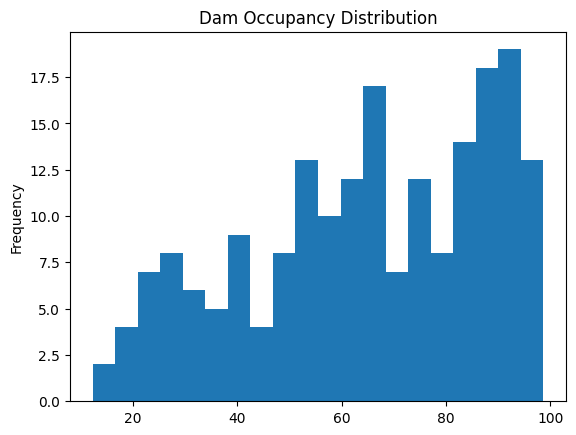

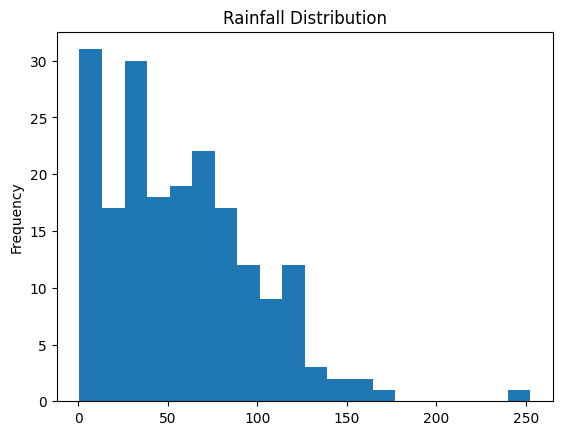

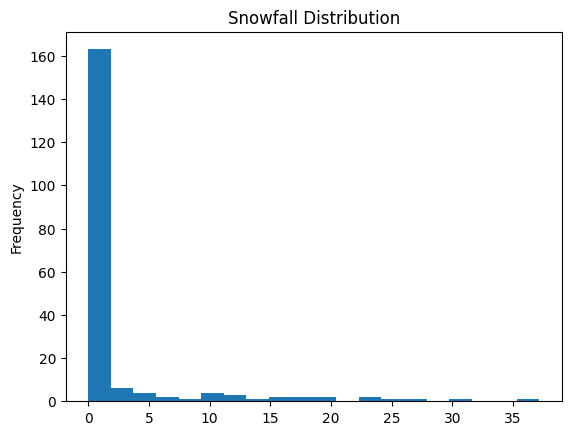

In [4]:
final_data["GENERAL_DAM_OCCUPANCY_RATE"].plot(kind="hist", bins=20)
plt.title("Dam Occupancy Distribution")
plt.show()

final_data["precipitation_sum (mm)"].plot(kind="hist", bins=20)
plt.title("Rainfall Distribution")
plt.show()

final_data["snowfall_sum (cm)"].plot(kind="hist", bins=20)
plt.title("Snowfall Distribution")
plt.show()

Dam occupancy values are mostly concentrated at higher levels (around 60–100%), suggesting that reservoirs are generally kept relatively full.

Rainfall is right-skewed, meaning most observations are low, with occasional extreme high rainfall events.

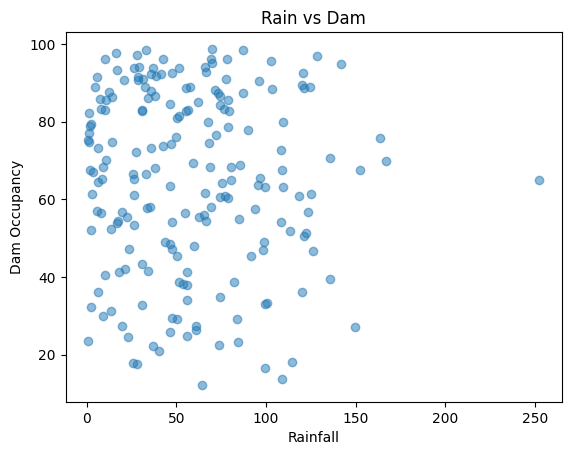

In [5]:
plt.scatter(
    final_data["precipitation_sum (mm)"],
    final_data["GENERAL_DAM_OCCUPANCY_RATE"],
    alpha=0.5
)

plt.xlabel("Rainfall")
plt.ylabel("Dam Occupancy")
plt.title("Rain vs Dam")
plt.show()

The scatter plot does not show a clear relationship between rainfall and dam occupancy. High rainfall values do not consistently correspond to high dam levels.

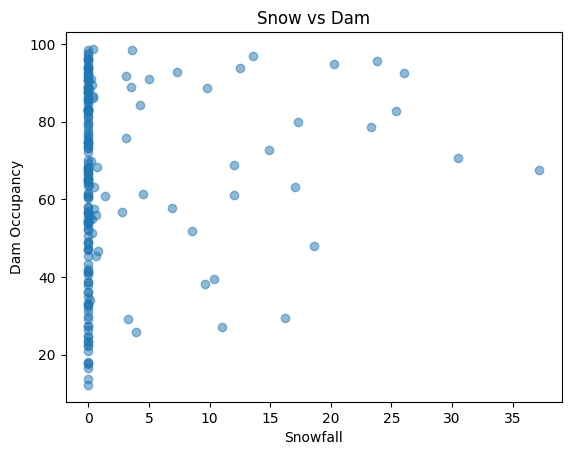

In [6]:
plt.scatter(
    final_data["snowfall_sum (cm)"],
    final_data["GENERAL_DAM_OCCUPANCY_RATE"],
    alpha=0.5
)

plt.xlabel("Snowfall")
plt.ylabel("Dam Occupancy")
plt.title("Snow vs Dam")
plt.show()

The scatter plot shows that snowfall is almost zero for most observations, and when it does occur, a clear relationship with dam occupancy is not seen. This suggests that snowfall is not a strong  predictor of reservoir levels.

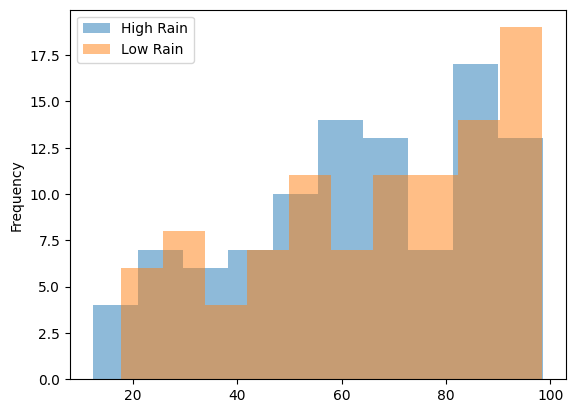

In [7]:
threshold = final_data["precipitation_sum (mm)"].median()

high_rain = final_data[final_data["precipitation_sum (mm)"] > threshold]
low_rain  = final_data[final_data["precipitation_sum (mm)"] <= threshold]

high_rain["GENERAL_DAM_OCCUPANCY_RATE"].plot(kind="hist", alpha=0.5, label="High Rain")
low_rain["GENERAL_DAM_OCCUPANCY_RATE"].plot(kind="hist", alpha=0.5, label="Low Rain")

plt.legend()
plt.show()

The distributions of dam occupancy under high and low rainfall conditions are very similar, indicating that rainfall level alone may not significantly affect reservoir occupancy.

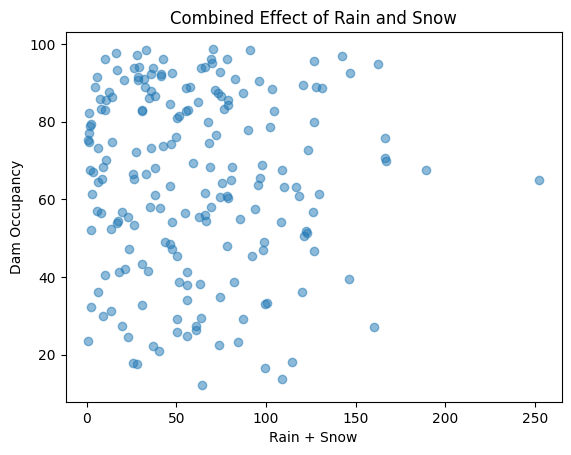

In [8]:
final_data["rain_snow_total"] = (
    final_data["precipitation_sum (mm)"] + final_data["snowfall_sum (cm)"])

plt.scatter(
    final_data["rain_snow_total"],
    final_data["GENERAL_DAM_OCCUPANCY_RATE"],
    alpha=0.5
)

plt.xlabel("Rain + Snow")
plt.ylabel("Dam Occupancy")
plt.title("Combined Effect of Rain and Snow")
plt.show()

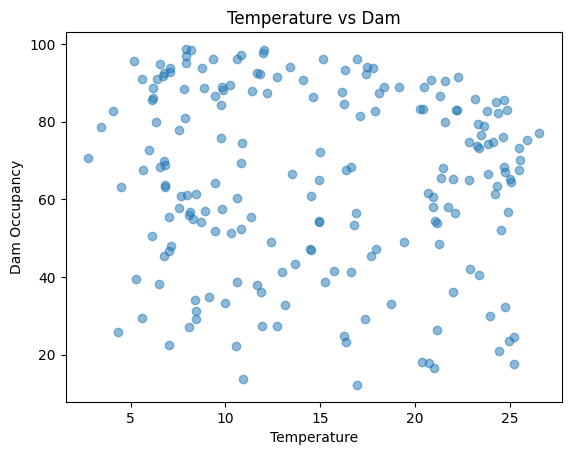

In [9]:
plt.scatter(
    final_data["temperature_2m_mean (°C)"],
    final_data["GENERAL_DAM_OCCUPANCY_RATE"],
    alpha=0.5
)

plt.xlabel("Temperature")
plt.ylabel("Dam Occupancy")
plt.title("Temperature vs Dam")
plt.show()

season
Fall      49.322261
Spring    80.446341
Summer    66.861588
Winter    62.274990
Name: GENERAL_DAM_OCCUPANCY_RATE, dtype: float64


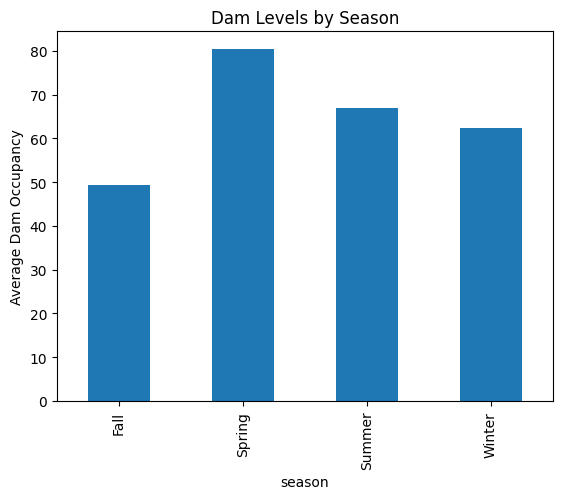

In [10]:
final_data["month"] = pd.to_datetime(final_data.index).month

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

final_data["season"] = final_data["month"].apply(get_season)

season_avg = final_data.groupby("season")["GENERAL_DAM_OCCUPANCY_RATE"].mean()
print(season_avg)

season_avg.plot(kind="bar")

plt.ylabel("Average Dam Occupancy")
plt.title("Dam Levels by Season")
plt.show()

Dam occupancy levels show strong seasonal patterns, with the highest levels in spring and the lowest in fall. This suggests that long-term seasonal dynamics, rather than short-term weather variables like rainfall, play a more significant role in determining reservoir levels.

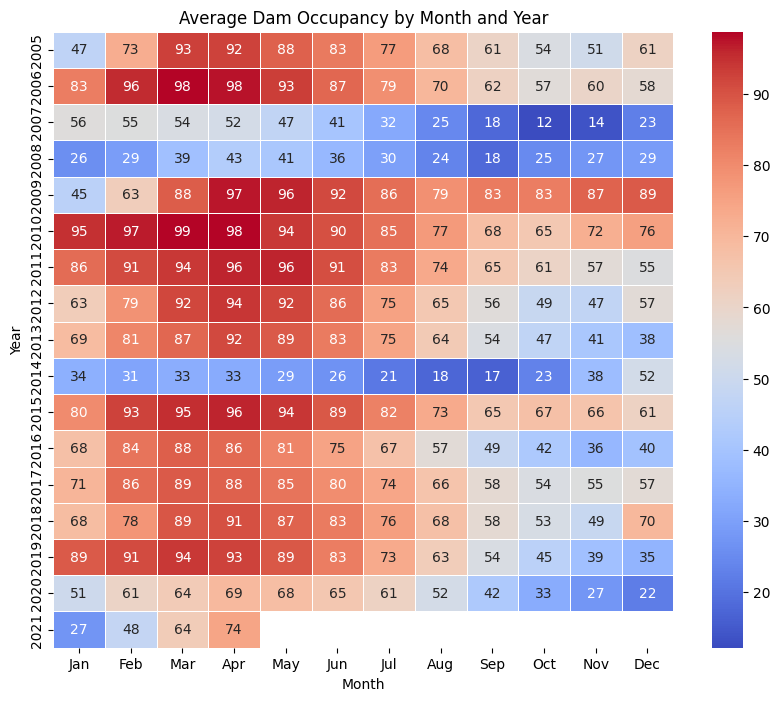

In [22]:
final_data["year"] = final_data.index.year
final_data["month"] = final_data.index.month

pivot_values = final_data.pivot_table(
    index="year",
    columns="month",
    values="GENERAL_DAM_OCCUPANCY_RATE",
    aggfunc="mean"
)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_values, cmap="coolwarm", linewidths=0.5, annot=True, fmt=".0f")

plt.title("Average Dam Occupancy by Month and Year")
plt.xlabel("Month")
plt.ylabel("Year")
plt.xticks(
    ticks=[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5],
    labels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
)

plt.show()

“The heatmap reveals a clear seasonal pattern in dam occupancy levels. Occupancy rates tend to be higher during late winter and spring months, likely due to increased precipitation, and gradually decline towards late summer and autumn. This suggests that seasonal factors play a significant role in explaining reservoir levels.”

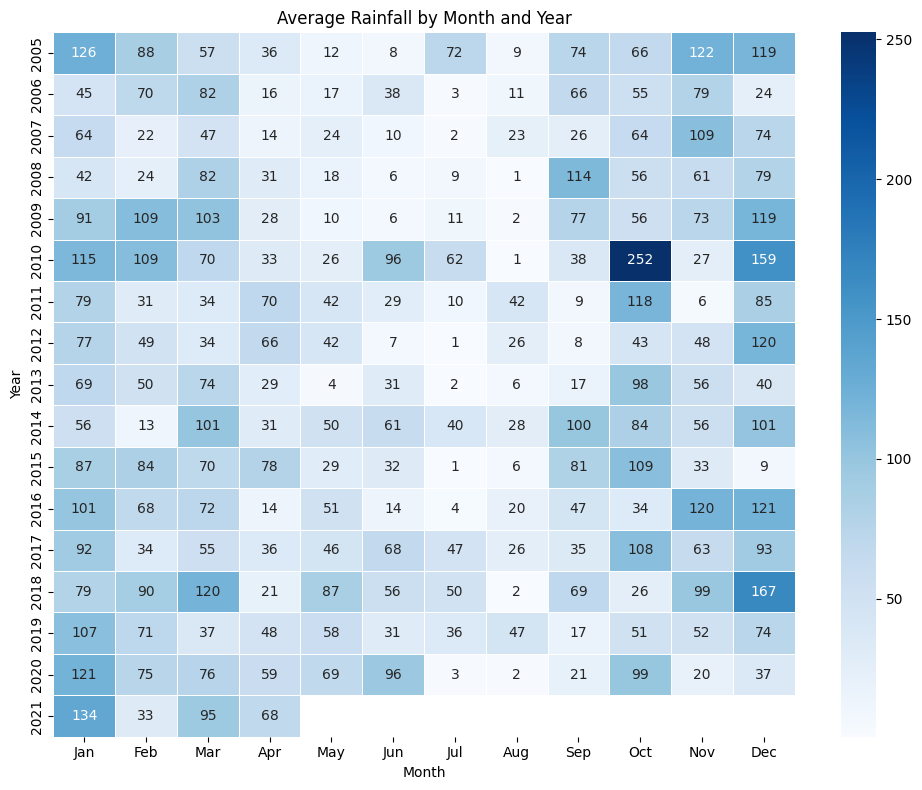

In [24]:
pivot_rain = final_data.pivot_table(
    index="year",
    columns="month",
    values="rain_sum (mm)",
    aggfunc="mean"
)


plt.figure(figsize=(10, 8))

sns.heatmap(
    pivot_rain,
    cmap="Blues",
    annot=True,
    fmt=".0f",
    linewidths=0.5
)

plt.title("Average Rainfall by Month and Year")
plt.xlabel("Month")
plt.ylabel("Year")

plt.xticks(
    ticks=[0.5,1.5,2.5,3.5,4.5,5.5,6.5,7.5,8.5,9.5,10.5,11.5],
    labels=["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
)

plt.tight_layout()
plt.show()

Rainfall levels vary across months and years, but the pattern appears less consistent compared to dam occupancy. While some seasonal variation exists, rainfall alone does not show a strong or stable pattern that directly explains reservoir levels.

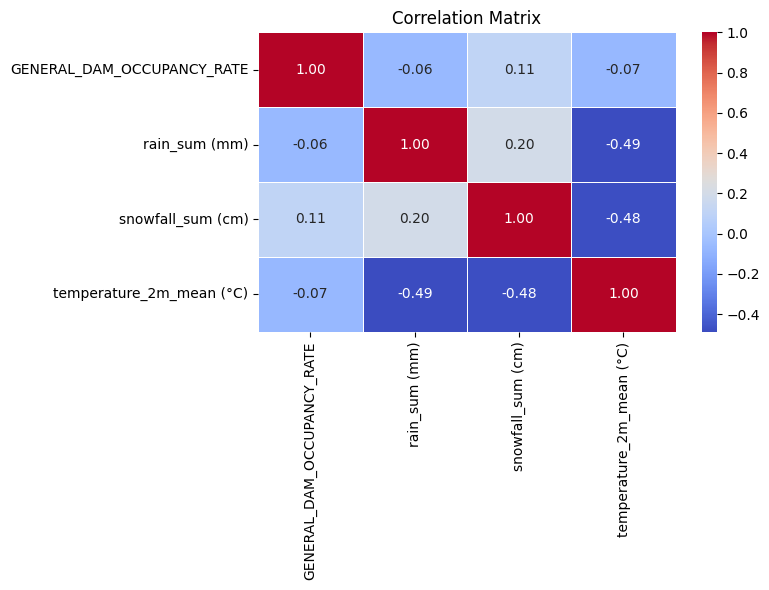

In [25]:
plt.figure(figsize=(8, 6))

corr = final_data[[
    "GENERAL_DAM_OCCUPANCY_RATE",
    "rain_sum (mm)",
    "snowfall_sum (cm)",
    "temperature_2m_mean (°C)"
]].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()